    "Scrivere il problema di Empirical Risk Minimization per una regressione lineare sui seguenti dati, utilizzando la Squared Error Loss\n",
    "| OBJECT ID | FEAT 1 | FEAT 2 | LABEL |\n",
    "|-|-|-|-|\n",
    "| a | 0 | 10 | 2 |\n",
    "| b | -1 | 9 | 0.5 |\n",
    "| c | 0 | 0 | 0 |\n",
    "| d | 98 | 99 | 100 |"

In [4]:
!pip install scikit-learn matplotlib numpy pandas plotly

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 5.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 5.6 MB/s eta 0:00:02
   ----------------- ---------------------- 3.4/8.0 MB 5.6 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.0 MB 5.8 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.0 MB 6.0 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.0 MB 6.0 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 4.6 MB/s  0:00:01
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8

In [5]:
pip install --upgrade nbformat


  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)

   ----- ---------------------------------- 1/7 [rpds-py]
   ----------- ---------------------------- 2/7 [attrs]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------------- 7/7 [nbformat]

Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

In [ ]:
X=np.array([[0,10],[-1,9],[0,0],[98,99]])  #feature
y=np.array([2,0.5,0,100])  #label

In [14]:
#REGRESSIONE LINERARE 
model=LinearRegression()
model.fit(X,y)
w_model=model.coef_   #(w=vettore dei coefficienti esempio y=Xw+b)
print(f"Coefficienti w: {w_model}")

Coefficienti w: [0.84251683 0.17614156]


In [20]:
#formula matematica per ottenere i coefficienti w a mano, senza la funzione w_model=model.coef_
#coefficienti w
w_analytical = np.linalg.inv(X.T @ X) @ X.T @ y
print(w_analytical)

[0.84271848 0.17591963]


In [16]:
#REGRESSIONE LINERARE con standarizzazione variabili
#per confrontare direttamente i coefficienti w è necessario che le variabili siano standarizzate
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_std=scaler.fit_transform(X) #standarizo le due variabili
model=LinearRegression()
model.fit(X_std,y)
w_model_std=model.coef_
print(f"Coefficienti w: {w_model_std}")

Coefficienti w: [35.87566366  7.10103938]


In [19]:

#coefficienti w da X_std
w_analytical_std = np.linalg.inv(X_std.T @ X_std) @ X_std.T @ y
print(w_analytical_std)

[35.87566366  7.10103938]


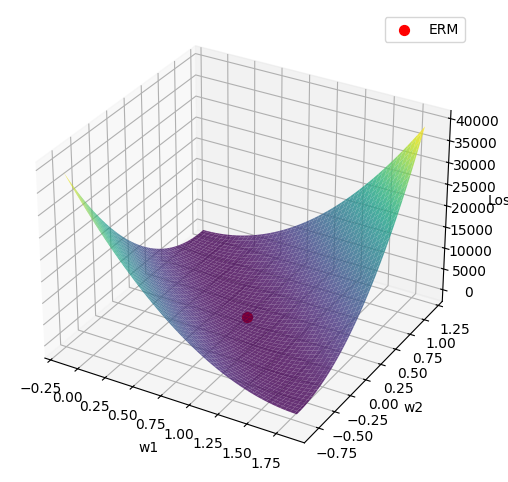

In [21]:
w1_vals = np.linspace(w_model[0] - 1, w_model[0] + 1, 100),
w2_vals = np.linspace(w_model[1] - 1, w_model[1] + 1, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)

loss = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w = np.array([W1[i,j], W2[i,j]])
        y_pred = X @ w
        loss[i, j] = np.sum((y - y_pred) ** 2)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, loss, cmap='viridis', alpha=0.8)
ax.scatter(w_model[0], w_model[1], np.sum((y - X @ w_model) ** 2),
           color='r', s=50, label='ERM')
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('Loss')
ax.legend()
plt.show()

In [22]:
fig = go.Figure(data=[go.Surface(z=loss, x=W1, y=W2, colorscale='Viridis', opacity=0.8)])
fig.add_trace(go.Scatter3d(
    x=[w_model[0]],
    y=[w_model[1]],
    z=[np.sum((y - X @ w_model)**2)],
    mode='markers',
    marker=dict(size=5, color='red'),
    name='ERM'
))

fig.update_layout(
    title='Loss 3D',
    scene=dict(
        xaxis_title='w1',
        yaxis_title='w2',
        zaxis_title='Squared Error Loss'
    )
)

print(f"Modello  : {w_model}")
print(f"Analitici: {w_analytical}")
fig.show()
   

Modello  : [0.84251683 0.17614156]
Analitici: [0.84271848 0.17591963]
